Aluna: Juliana Pierrobon Lopez
<br>Disciplina: Estatística Descritiva
<br>MBA Ciência de Dados e Inteligência Artificial Aplicadas - Enap
<br>Dados: Desmatamento em Unidades de Conservação Federais
<br>Março de 2025

### bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import statsmodels.api as sm

### dataset

In [2]:
df_baseED = pd.read_excel('https://github.com/JuPLopez/JL_mba_enap/raw/refs/heads/main/Estatistica_Descritiva/df_baseED.xlsx')
df_baseED = df_baseED.drop(columns=['Unnamed: 0'])

# 1. Variáveis
O dataset df_baseED possui registro dos dados de 297 Unidades de Conservação federais em 27 campos. 
<br>Os campos (0) cnuc, (1) unidade de conservação e (19) Nome da UC são identificadores da Unidade de Conservação (UC). Os demais campos correspondem às variáveis descritas a seguir.
- (2) área_ha_uc: variável quantivativa contínua
<br>Indica a área da Unidade de Conservação, em hectares.
- (3) 2008, (4) 2009, (5) 2010, (6) 2011, (7) 2012, (8) 2013, (9) 2014, (10) 2015, (11) 2016, (12) 2017, (13) 2018, (14) 2019, (15) 2020, (16) 2021, (17) 2022, (18) 2023: variáveis quantivativas contínuas
<br>Indica a área desmatada anualmente em cada da Unidade de Conservação, em hectares.
- (20) UF: variável qualitativa nominal
<br>Indica a(s) Unidade(s) Federativa(s) abrangidas pela Unidade de Conservação.
- (21) Plano de Manejo: variável qualitativa nominal 
<br>Indica se a Unidade de Conservação tem plano de manejo publicado.
- (22) Categoria (Sigla): variável qualitativa nominal 
<br>Indica a que categoria de conservação a Unidade de Conservação pertence (SNUC).
- (23) Grupo (Sigla): variável qualitativa nominal 
<br>Indica a que grupo de conservação (Proteção Integral ou Uso Sustentável) a Unidade de Conservação pertence (SNUC).
- (24) Bioma: variável qualitativa nominal 
<br>Indica o bioma predominante na Unidade de Conservação pertence predominanárea desmatada anualmente em cada da Unidade de Conservação, em hectares.
- (25) Ano de Criação: variável quantitativa discreta
<br>Indica o ano de criação da Unidade de Conservação
- (26) TotalDesmat: variável quantivativa contínua 
<br>Indica a área desmatada em cada da Unidade de Conservação, em hectares, no período de 2008 a 2023.
- (27) %Desmat:: variável quantivativa contínua
<br>Indica a porcentagem de área desmatada da Unidade de Conservação, em hectares, no período de 2008 a 2023.

In [3]:
df_baseED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cnuc                    297 non-null    object 
 1   unidade de conservação  297 non-null    object 
 2   área_ha_uc              297 non-null    float64
 3   2008                    297 non-null    float64
 4   2009                    297 non-null    float64
 5   2010                    297 non-null    float64
 6   2011                    297 non-null    float64
 7   2012                    297 non-null    float64
 8   2013                    297 non-null    float64
 9   2014                    297 non-null    float64
 10  2015                    297 non-null    float64
 11  2016                    297 non-null    float64
 12  2017                    297 non-null    float64
 13  2018                    297 non-null    float64
 14  2019                    297 non-null    fl

# 2. Distribuição da frequência por variável

## i) Área da UC (ha)
- Grande amplitude, abrangendo áreas de 89 a mais de 1.000.000 hectares
- Desbalanceamento: concentração de valores até 500.000ha. 

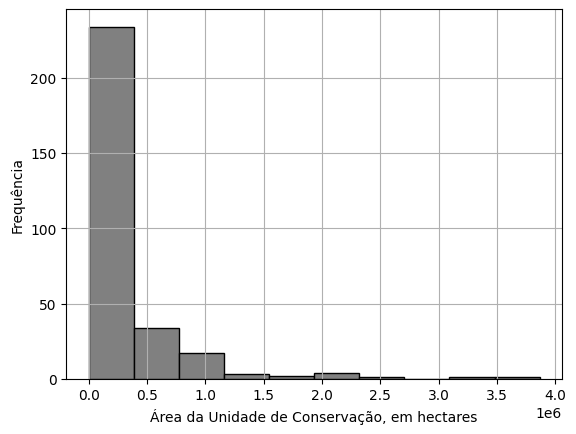

In [4]:
df_baseED['área_ha_uc'].hist(edgecolor='black', color='grey')
plt.xlabel('Área da Unidade de Conservação, em hectares')
plt.ylabel('Frequência')
plt.show()

## ii) Área total desmatada (anual e cumulativa, período de 2008 a 2023)
São 16 varíáveis quantitativas contínuas que indicam a área desmatada anualmente em cada UC, e 1 que indica o total da área desmatada em todo o período de 2008 a 2023. Para exemplificar a distribuição dos valores dessas variáveis, foi utilizada a variável da área total desmatada no período de 2008 a 2023.
- Grande amplitude
- Desbalanceamento: concentração de valores até aproximadamente 10.000ha.

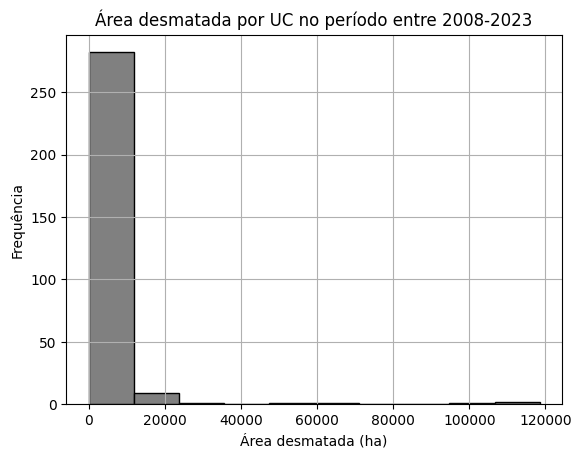

In [5]:
# Plotando o histograma
df_baseED["TotalDesmat"].hist(edgecolor='black', color = 'grey')

plt.xlabel('Área desmatada (ha)')
plt.ylabel('Frequência')
plt.title('Área desmatada por UC no período entre 2008-2023')
plt.show()


Text(0.5, 1.0, 'Área desmatada por Unidade de Conservação, em hectares')

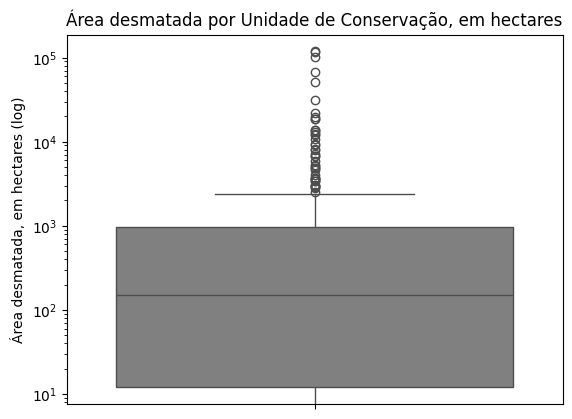

In [6]:
sns.boxplot(df_baseED["TotalDesmat"], color='grey')
plt.yscale("log") 
plt.ylabel('Área desmatada, em hectares (log)')
plt.title('Área desmatada por Unidade de Conservação, em hectares')


## iii) % de Área Desmatada
- Identificação de um outlier (>40%)
- Desbalanceamento: Muitas UCs com 0% de área desmatada 

Text(0.5, 1.0, '% de área desmatada por Unidade de Conservação')

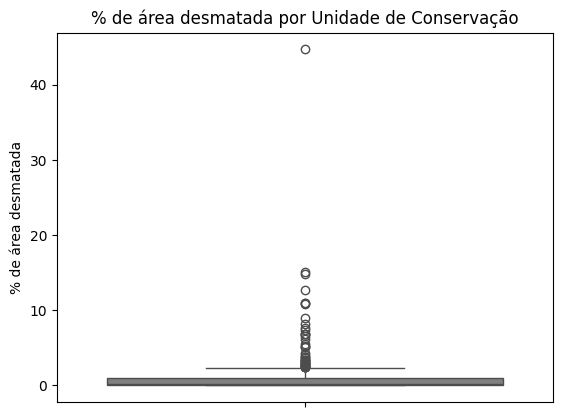

In [7]:
sns.boxplot(df_baseED["%Desmat"], color='grey')
plt.ylabel('% de área desmatada')
plt.title('% de área desmatada por Unidade de Conservação')


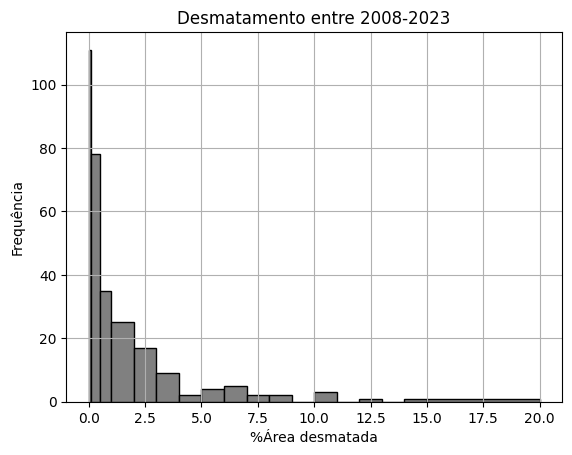

In [8]:
bins = [0, 0.1, 0.5, 1, 2, 3, 4,5,6,7,8,9,10,11,12,13,14,15,20] 

# Plotando o histograma
df_baseED["%Desmat"].hist(bins = bins, edgecolor='black', color = 'gray')
plt.xlabel('%Área desmatada')
plt.ylabel('Frequência')
plt.title('Desmatamento entre 2008-2023')
plt.show()


## iv) UF
- UCs podem abranger uma ou mais UFs
- Desbalanceamento: PA, AM e BA juntos corresponde a quase metade de UFs abrangidas 

<Axes: xlabel='UF'>

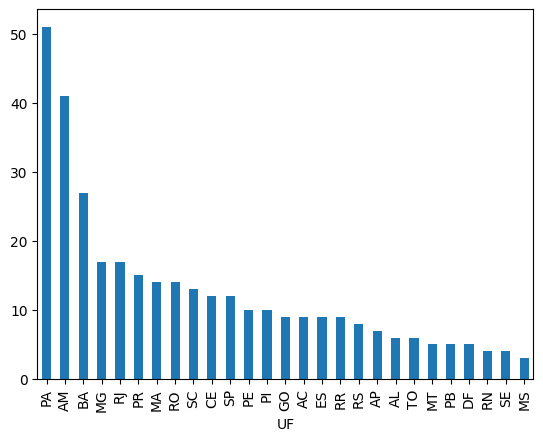

In [9]:
df_baseED_UF = df_baseED.assign(UF=df_baseED['UF'].str.split(', ')).explode('UF')
df_baseED_UF['UF'].value_counts().plot(kind='bar')

## v) Plano de Manejo

Plano de Manejo
Sim               162
Sem Informação     98
Não                37
Name: count, dtype: int64


<Axes: xlabel='Plano de Manejo'>

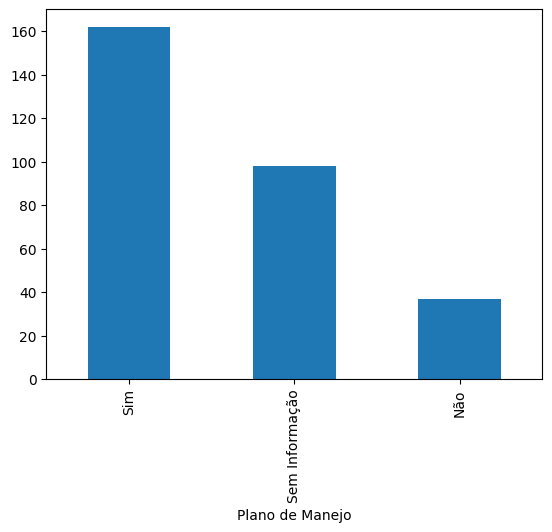

In [10]:
print(df_baseED['Plano de Manejo'].value_counts()) 
df_baseED['Plano de Manejo'].value_counts().plot(kind='bar')

## vi) Grupo

Grupo (Sigla)
PI    127
US    170
Name: count, dtype: int64


<Axes: xlabel='Grupo (Sigla)'>

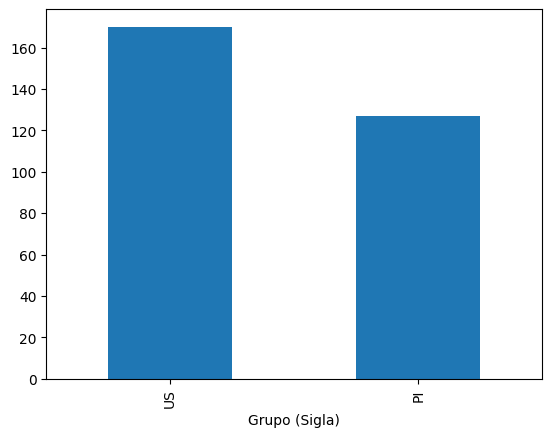

In [11]:
print(df_baseED['Grupo (Sigla)'].value_counts().sort_index())
df_baseED['Grupo (Sigla)'].value_counts().plot(kind='bar')

## vii) Categoria de Manejo
- Desbalanceamento: predomínio das categorias Parque Nacional, Reserva Extrativista e Floresta Nacional; categorias minoritárias - ARIEs, RVS, RDS e MONA

Categoria (Sigla)
PARNA    70
RESEX    64
FLONA    63
APA      34
REBIO    27
ESEC     22
ARIE      7
RVS       6
RDS       2
MONA      2
Name: count, dtype: int64


<Axes: xlabel='Categoria (Sigla)'>

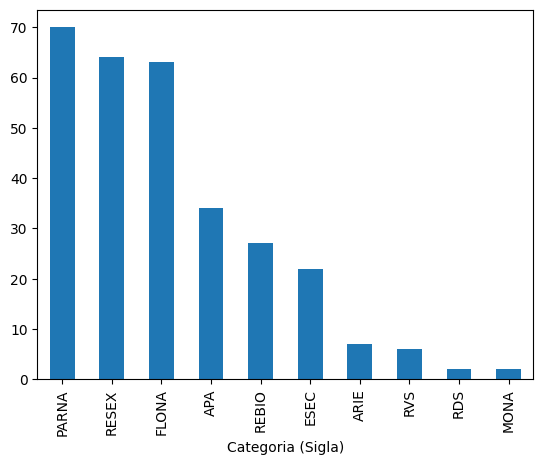

In [12]:
print(df_baseED['Categoria (Sigla)'].value_counts().sort_values(ascending=0)) 
df_baseED['Categoria (Sigla)'].value_counts().plot(kind='bar')

## viii) Bioma
- Desbalanceamento: predomínio do bioma Amazônia; bioma minoritário - Pampa

Bioma
Pampa               3
Marinho            15
Caatinga           28
Cerrado            39
Mata Atlântica     84
Amazônia          128
Name: count, dtype: int64


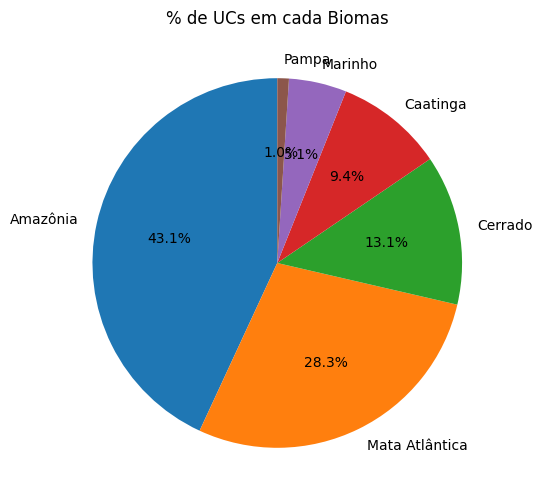

In [13]:
print(df_baseED['Bioma'].value_counts().sort_values())

contagem_bioma = df_baseED['Bioma'].value_counts()

# Gráfico de pizza
contagem_bioma.plot(kind='pie', autopct='%.1f%%', startangle=90, figsize=(6, 6))
plt.title('% de UCs em cada Biomas')
plt.ylabel('')  # Remove o label do eixo y
plt.show()


## ix) Ano de criação
- Desbalanceamento: concentração na década de 2000.

count     297.000000
mean     1995.175084
std        15.300911
min      1934.000000
25%      1986.000000
50%      2000.000000
75%      2006.000000
max      2023.000000
Name: Ano de Criação, dtype: float64


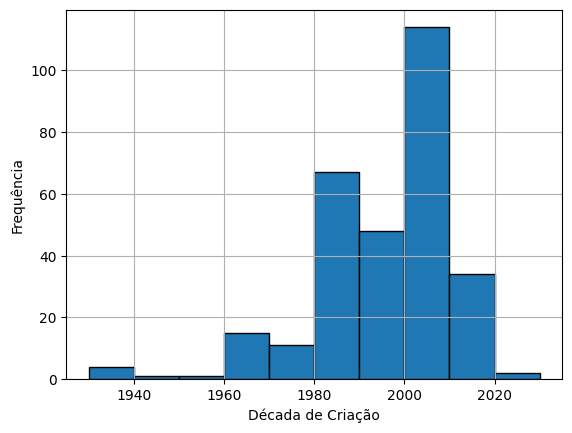

In [14]:
print(df_baseED['Ano de Criação'].describe())

bins = [1930,1940,1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030] 

# Plotando o histograma
df_baseED['Ano de Criação'].hist(bins=bins, edgecolor='black')
plt.xlabel('Década de Criação')
plt.ylabel('Frequência')
plt.show()

# 3. Medidas de tendência central

- Área da Unidade de Conservação
<br> A média, a mediana e a moda desta variável são diferentes entre si, sendo que a moda tem o menor valor 20.714ha, seguida pela mediana (76.410ha) e depois pela média (269.095ha). Essas características (média > mediana > moda) demonstram uma assimetria positiva, com uma cauda à direita longa. 
<br>A média geométrica é 51.832ha e a harmônica é 2.727ha.

Considerando que a presença de outliers à direita da curva (representada no boxplot do item 4), a média geométrica (mais resistente a outliers) pode ser considerada mais adequada para representar o conjunto de dados.


In [15]:
media = (df_baseED["área_ha_uc"]).mean()
mediana = (df_baseED["área_ha_uc"]).median()

from statistics import mode
try:
    moda = mode(df_baseED["área_ha_uc"])
except StatisticsError:
    moda = "Não há moda única"  

mediageometrica = stats.gmean(df_baseED["área_ha_uc"])
mediaharmonica =stats.hmean(df_baseED["área_ha_uc"])

print(f"A média da Área por UC é {media:.2f}ha.\n"
      f"A mediana da Área por UC é {mediana:.2f}ha.\n"
      f"A moda da Área por UC é {moda}ha.\n"
      f"A média geométrica da Área por UC é {mediageometrica}ha e a harmônica é {mediaharmonica}ha.\n")

A média da Área por UC é 269095.51ha.
A mediana da Área por UC é 76410.04ha.
A moda da Área por UC é 20714.672972ha.
A média geométrica da Área por UC é 51832.20597290322ha e a harmônica é 2727.7846112246175ha.



1. Linha azul = moda
2. Linha verde = média 
3. Linha cinza = mediana

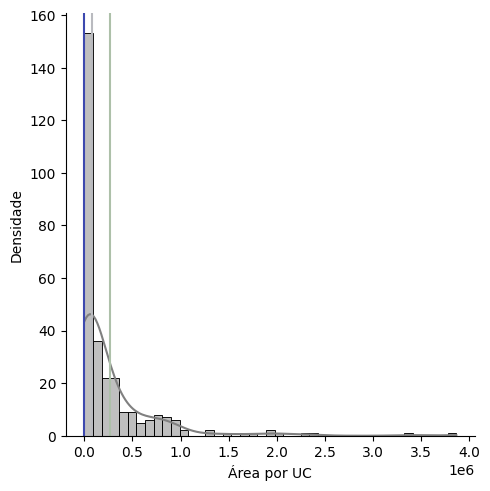

In [16]:
ax = sns.displot(df_baseED, x="área_ha_uc", kde=True, color = 'gray')
ax.set(xlabel='Área por UC', ylabel='Densidade')
plt.axvline(x=df_baseED["área_ha_uc"].mode().all(), color='#3d49afff')
plt.axvline(x=df_baseED["área_ha_uc"].mean(), color='#adc0a9ff')
plt.axvline(x=df_baseED["área_ha_uc"].median(), color='#b9babfff')
plt.savefig('AreaUC_centrais.png')  # Salva como PNG

# 4. Medidas separatrizes
- Área da Unidade de Conservação
<br> Conforme pode ser observado no boxplot a seguir, há outliers na amostra.
<br> O valor mínimo (limite inferior) do boxplot é -445.817,1 ha e não há valores abaixo dele. Por ser uma medida de área, não existem registros 0 ou negativos, sendo os valores da amostra sempre positivos.
<br> O valor máximo (limite superior) é 774.353,7 ha e foram registrados 29 valores acima deles.

<br>Outliers: 1      2.040336e+06; 5      3.373152e+06; 11     8.313497e+05; 15     1.061956e+06; 23     9.694248e+05; 28     8.651185e+05; 32     1.942318e+06; 36     1.470179e+06;
38     1.301565e+06; 48     1.066289e+06;
49     8.375567e+05; 
53     8.962375e+05; 
55     8.628921e+05; 
56     2.367341e+06; 
57     1.957028e+06; 
59     2.252411e+06; 
62     9.613137e+05; 
64     1.776924e+06; 
65     3.865169e+06; 
66     8.085987e+05; 
78     9.386028e+05; 
86     9.315308e+05; 
107    7.747718e+05; 
121    8.405159e+05; 
127    1.289309e+06; 
255    9.336793e+05; 
283    9.290430e+05; 
285    1.622418e+06; 
288    8.238452e+05. 

<br> O primeiro quartil é 11.746,9 ha e o terceiro, 316.789,6 ha.


Text(0.5, 1.0, 'Área da Unidade de Conservação, em hectares')

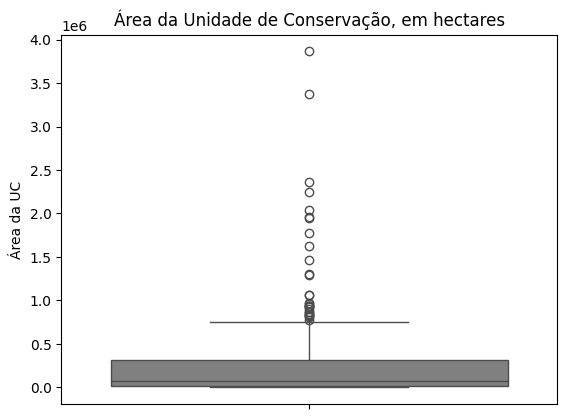

In [17]:
sns.boxplot(df_baseED["área_ha_uc"], color='grey')
plt.ylabel('Área da UC')
plt.title('Área da Unidade de Conservação, em hectares')

In [18]:
Q1 = df_baseED['área_ha_uc'].quantile(.25)
Q3 = df_baseED['área_ha_uc'].quantile(.75)
IQR = Q3 - Q1

# Calculando os limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificando outliers
outliers = df_baseED['área_ha_uc'][(df_baseED['área_ha_uc'] < limite_inferior) | (df_baseED['área_ha_uc'] > limite_superior)]

print(f"Q1: {Q1:.1f} ha")
print(f"Q3: {Q3:.1f} ha")
print(f"IQR: {IQR:.1f} ha")
print(f"Limite Inferior: {limite_inferior:.1f} ha")
print(f"Limite Superior: {limite_superior:.1f} ha")
print(f"Outliers: {outliers}")

Q1: 11746.9 ha
Q3: 316789.6 ha
IQR: 305042.7 ha
Limite Inferior: -445817.1 ha
Limite Superior: 774353.7 ha
Outliers: 1      2.040336e+06
5      3.373152e+06
11     8.313497e+05
15     1.061956e+06
23     9.694248e+05
28     8.651185e+05
32     1.942318e+06
36     1.470179e+06
38     1.301565e+06
48     1.066289e+06
49     8.375567e+05
53     8.962375e+05
55     8.628921e+05
56     2.367341e+06
57     1.957028e+06
59     2.252411e+06
62     9.613137e+05
64     1.776924e+06
65     3.865169e+06
66     8.085987e+05
78     9.386028e+05
86     9.315308e+05
107    7.747718e+05
121    8.405159e+05
127    1.289309e+06
255    9.336793e+05
283    9.290430e+05
285    1.622418e+06
288    8.238452e+05
Name: área_ha_uc, dtype: float64


# 5. Medidas de dispersão
- Porcentagem de área desmatada no período de 2008 a 2023, por UC.

1. A amostra é concentrada nos valores de área desmatada <1% (aproximadamente).
<br>A amplitude interna (IIQ = 0,9%, sendo Q1 = 0.0 e Q3 = 1.0 ) não é proporcional à amplitude total da amostra (44,%) e pode ser explicada pela concentração de valores ao redor da média aliada à existência de valores extremos.
<br>Essas informações indicam que a maior parte das UCs registram desmatamento abaixo de 1% de sua área (pelo menos 25% das UCs tem desmatamento 0), enquanto algumas registram desmatamentos bem maiores, chegando ao máximo de 44%.
2. Assimetria
<br>- média (1.25%) > mediana (0.23%) > moda (0.0%)
<br>- Terceiro Momento Central: 315.1
<br>- Essas características (média > mediana > moda) e Terceiro Momento Central positivo e alto demonstram uma forte assimetria positiva, com cauda longa à direita longa. Ou seja, valores muito maiores que a média puxam a distribuição para a direita. 
3. Curtose
<br> - Quarto Momento Central: 12439.6
<br>- O alto valor positivo do Quarto Momento Central indica uma distribuição leptocúrtica, com caudas extremamente pesadas e pico muito acentuado (maioria dos dados concentrada em torno da média, com dispersão muito pequena). Também aponta para a presença de outliers extremos.

4. Como demonstrado, a amostra contém valores extremos (outliers). A identificação desses valores, para posterior remoção, poderia ser feita com uso a) do Intervalo Interquartílicol (IIQ) (valores abaixo de Q1−1.5×IQRQ1−1.5×IQR e acima de Q3+1.5×IQRQ3+1.5×IQR) ou b) do Desvio Padrão (valores além de 2 ou 3 desvios padrão da média). 

In [19]:
# média
media_Desmat = df_baseED["%Desmat"].mean()
# moda
moda_Desmat = df_baseED["%Desmat"].mode().all()
# variância
S2_Desmat = df_baseED["%Desmat"].var()
# desvio padrão 
S_Desmat = df_baseED["%Desmat"].std()
# desvios absoluto médio
DAM_Desmat = np.abs(df_baseED["%Desmat"] - df_baseED["%Desmat"].mean()).mean()
# desvios absoluto mediano
MAD_Desmat = np.median(np.absolute(df_baseED["%Desmat"] - df_baseED["%Desmat"].median()))
# amplitude
A_Desmat = df_baseED["%Desmat"].max() - df_baseED["%Desmat"].min()
# intervalo interquartílico
Q1_Desmat = df_baseED["%Desmat"].quantile(0.25)
Q3_Desmat = df_baseED["%Desmat"].quantile(0.75)
IIQ_Desmat = Q3_Desmat - Q1_Desmat
# coeﬁciente de dispersão quartílica 
CDQ_Desmat = IIQ_Desmat / (Q3_Desmat + Q1_Desmat)
# coeﬁciente de variação
CV_Desmat = (S_Desmat / df_baseED["%Desmat"].mean()) * 100


print(f"A média da porcentagem de área desmatada é de {media_Desmat:.1f}.\n"
f"A moda da porcentagem de área desmatada é de {moda_Desmat:.1f}.\n"
f"A variância da porcentagem de área desmatada é de {S2_Desmat:.1f}.\n"
f"O devio padrão da porcentagem de área desmatada é de {S_Desmat:.1f}.\n"
f"O desvio absoluto médio da porcentagem de área desmatada é de {DAM_Desmat:.1f}.\n"
f"O desvio absoluto mediano da porcentagem de área desmatada é de {MAD_Desmat:.1f}.\n"
f"A amplitude da porcentagem de área desmatada é de {A_Desmat:.1f}.\n"
f"O intervalo interquartílico da porcentagem de área desmatada é de {IIQ_Desmat:.1f}. Q1:{Q1_Desmat:.1f} e Q3: {Q3_Desmat:.1f} \n"
f"O coeﬁciente de dispersão quartílica da porcentagem de área desmatada é de {CDQ_Desmat:.1f}.\n"
f"O coeﬁciente de variação da porcentagem de área desmatada é de {CV_Desmat:.1f}.\n")

A média da porcentagem de área desmatada é de 1.2.
A moda da porcentagem de área desmatada é de 0.0.
A variância da porcentagem de área desmatada é de 11.5.
O devio padrão da porcentagem de área desmatada é de 3.4.
O desvio absoluto médio da porcentagem de área desmatada é de 1.6.
O desvio absoluto mediano da porcentagem de área desmatada é de 0.2.
A amplitude da porcentagem de área desmatada é de 44.7.
O intervalo interquartílico da porcentagem de área desmatada é de 0.9. Q1:0.0 e Q3: 1.0 
O coeﬁciente de dispersão quartílica da porcentagem de área desmatada é de 0.9.
O coeﬁciente de variação da porcentagem de área desmatada é de 272.3.



- linhas cinzas: componentes do IIQ (i.e. Q1 e Q3)
- linha azuis: média, primeiro desvio padrão à esquerda e primeiro à direita

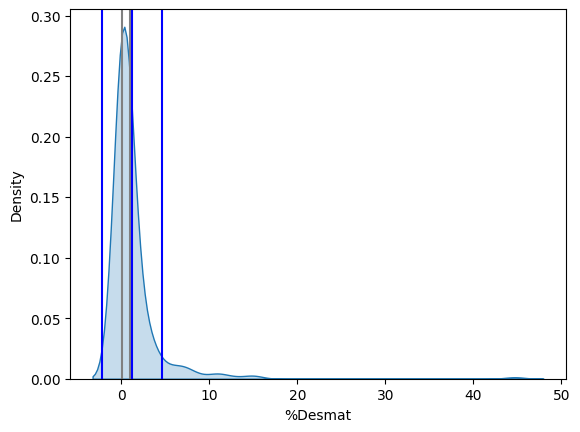

In [20]:
sns.kdeplot(df_baseED["%Desmat"], fill=True, label='Densidade')
ax.set(xlabel='% Área desmatada', ylabel='Densidade')

# IIQ
plt.axvline(x=Q1_Desmat, color='grey')
plt.axvline(x=Q3_Desmat, color='grey')

# Desvio Padrao
xbar_Desmat = df_baseED["%Desmat"].mean()
plt.axvline(x=xbar_Desmat, color='blue')
plt.axvline(x=xbar_Desmat-S_Desmat, color='blue')
plt.axvline(x=xbar_Desmat+S_Desmat, color='blue')


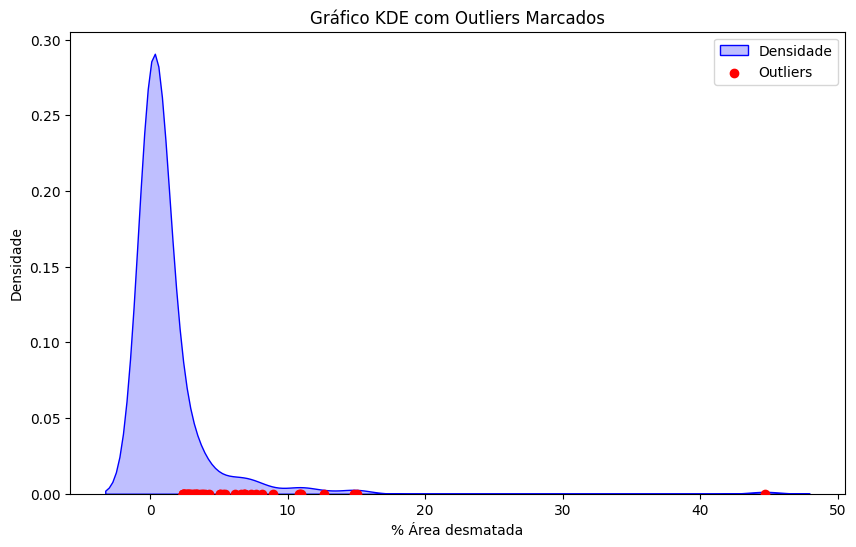

In [21]:
# Calculando os quartis e o intervalo interquartil (IQR)
Q1 = df_baseED["%Desmat"].quantile(0.25)
Q3 = df_baseED["%Desmat"].quantile(0.75)
IQR = Q3 - Q1
# Definindo os limites para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
# Identificando os outliers
outliers = df_baseED["%Desmat"][(df_baseED["%Desmat"] < limite_inferior) | (df_baseED["%Desmat"] > limite_superior)]

# Plotando o gráfico KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(df_baseED["%Desmat"], fill=True, color="blue", label='Densidade')

# Marcando os outliers no gráfico
if not outliers.empty:
    plt.scatter(outliers, np.zeros_like(outliers), color='red', label='Outliers', zorder=5)

# Adicionando título e rótulos
plt.title('Gráfico KDE com Outliers Marcados')
plt.xlabel('% Área desmatada')
plt.ylabel('Densidade')
plt.legend()

# Exibindo o gráfico
plt.show()

In [22]:
media = (df_baseED["%Desmat"]).mean()
mediana = (df_baseED["%Desmat"]).median()

from statistics import mode
try:
    moda = mode(df_baseED["%Desmat"])
except StatisticsError:
    moda = "Não há moda única"  
print(f"A média da Área por UC é {media:.2f}%.\n"
      f"A mediana da Área por UC é {mediana:.2f}%.\n"
      f"A moda da Área por UC é {moda}%.\n")

A média da Área por UC é 1.25%.
A mediana da Área por UC é 0.23%.
A moda da Área por UC é 0.0%.



In [23]:
media = df_baseED["%Desmat"].mean()
terceiro_momento_central = ((df_baseED["%Desmat"] - media) ** 3).mean()

print("Terceiro Momento Central:", terceiro_momento_central)

Terceiro Momento Central: 315.14501870016056


In [24]:
media = (df_baseED["%Desmat"]).mean()

quarto_momento_central = (((df_baseED["%Desmat"]) - media) ** 4).mean()
print("Quarto Momento Central:", quarto_momento_central)

Quarto Momento Central: 12439.655850138772


# 6. Relação entre duas variáveis

## A) Gráfico de dispersão, do tipo KDE, da variável contínua, particionado por variável qualitativa.


In [25]:
# Contando valores = 0
contagem_zero = (df_baseED["%Desmat"] == 0).sum()
contagem_zero

34

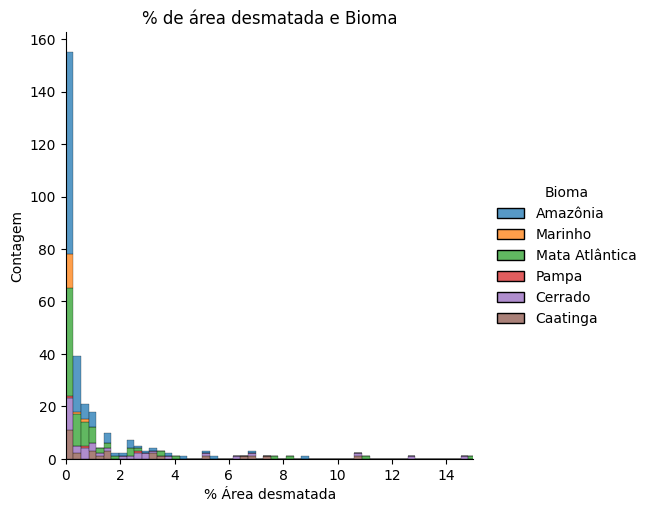

In [26]:
sns.displot(data=df_baseED, x="%Desmat", hue="Bioma", multiple="stack")

# Definindo o limite máximo do eixo x (excluir outlier)
plt.xlim(0, 15) 

# Ajustes estéticos
plt.title("% de área desmatada e Bioma")
plt.xlabel("% Área desmatada")
plt.ylabel("Contagem")
plt.show()


## B) Gráfico Scatter Plot de duas váriáveis contínuas

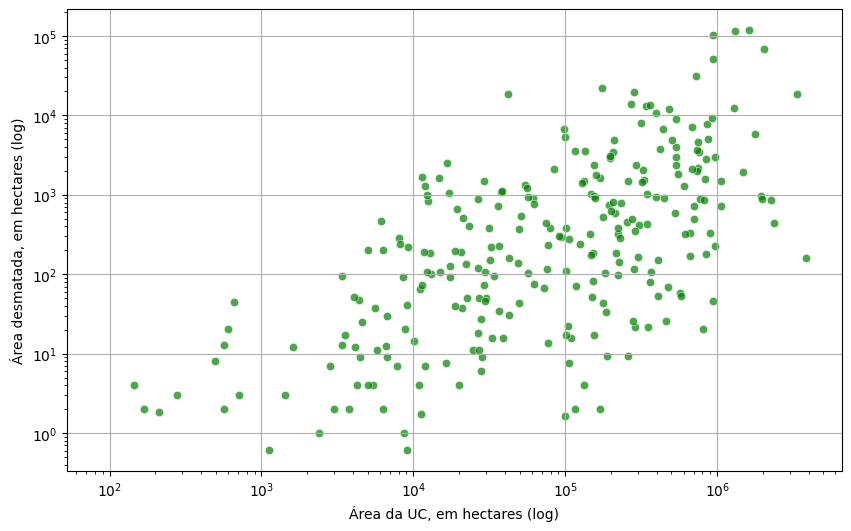

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='área_ha_uc',  # Variável no eixo x
    y='TotalDesmat',    # Variável no eixo y
    data=df_baseED,     # DataFrame ****
    alpha=0.7,
    color="green"
)

# Adicionando rótulos e título
#plt.title("")
plt.xlabel("Área da UC, em hectares (log)")
plt.ylabel("Área desmatada, em hectares (log)")
plt.xscale("log")  
plt.yscale("log")  
plt.grid(True)
plt.show()

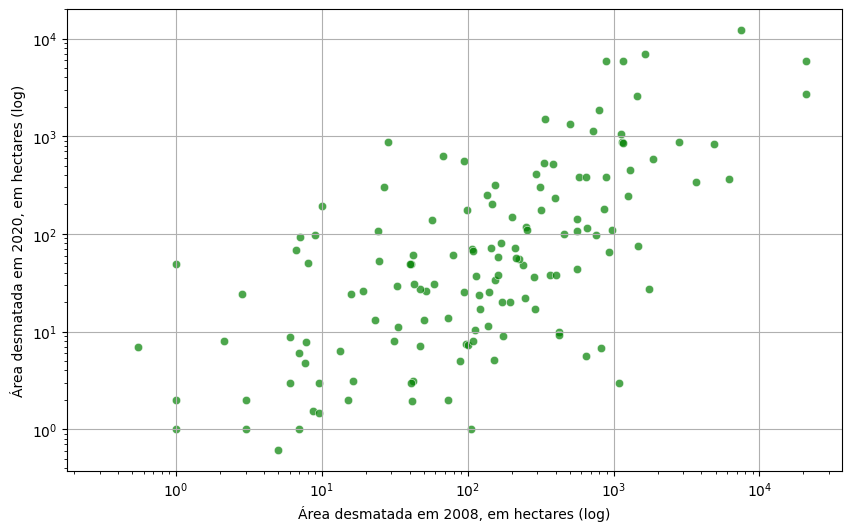

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=2008,  # Variável no eixo x
    y=2020,    # Variável no eixo y
    data=df_baseED,     # DataFrame ****
    alpha=0.7,
    color="green"
)

# Adicionando rótulos e título
#plt.title("")
plt.xlabel("Área desmatada em 2008, em hectares (log)")
plt.ylabel("Área desmatada em 2020, em hectares (log)")
plt.xscale("log")  
plt.yscale("log")  
plt.grid(True)
plt.show()

## C) Gráfico violino
- Diferença de dispersão entre as amostras

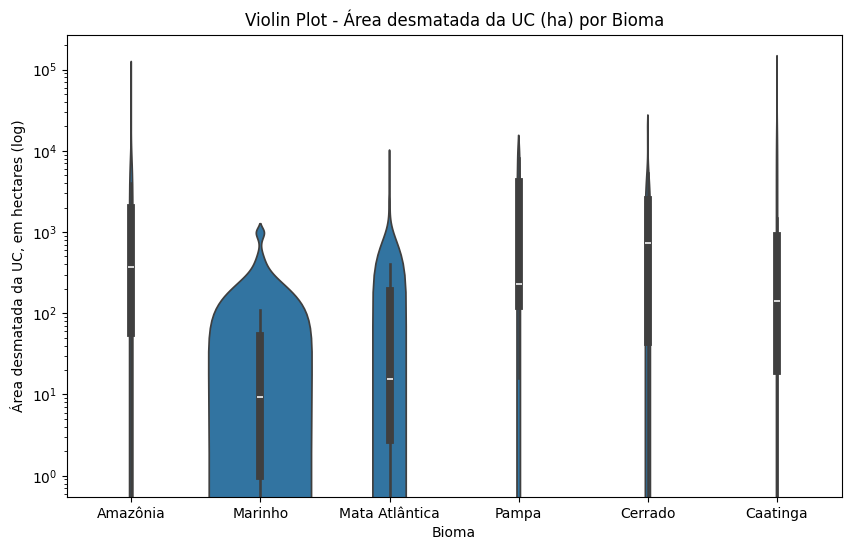

In [29]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Bioma', y='TotalDesmat', data=df_baseED)

# Adicionar título e rótulos
plt.title("Violin Plot - Área desmatada da UC (ha) por Bioma")
plt.xlabel('Bioma')
plt.ylabel('Área desmatada da UC, em hectares (log)')
plt.yscale('log')
plt.show()

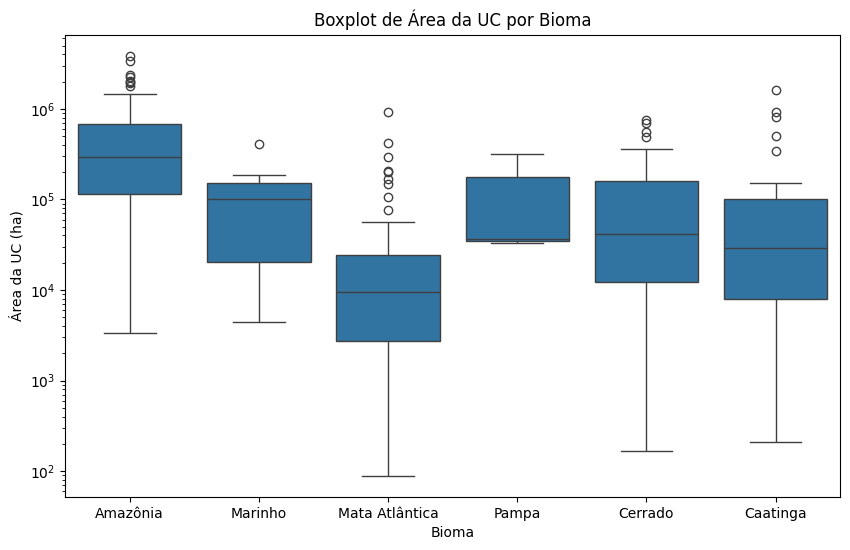

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Bioma', y='área_ha_uc', data=df_baseED)

# Adicionar título e rótulos
plt.title('Boxplot de Área da UC por Bioma')
plt.xlabel('Bioma')
plt.ylabel('Área da UC (ha)')
plt.yscale('log')
plt.show()

## D) Medidas de associação entre duas variáveis categóricas
1. V de Cramer = 0.2837: Associação fraca entre as variáveis.
2. p-valor = 0.000226: A associação é estatisticamente significativa.
3. Coeficiente de Contingência (0.2729): Associação muito fraca entre as variáveis

<br>A associação entre as variáveis é estatisticamente significativa (p-valor < 0,05). No entanto, a magnitude da associação é fraca, conforme indicado pelo V de Cramer e pelo Coeficiente de Contingência. Isso significa que, embora haja uma relação significativa entre as variáveis, ela não é forte o suficiente para ser considerada relevante em termos práticos.


In [31]:
# Cria a tabela de contingência
tabela = pd.crosstab(df_baseED['Bioma'], df_baseED['Grupo (Sigla)'])
display(tabela)

# Aplica o teste qui-quadrado
chi2, p, dof, expected = chi2_contingency(tabela)

# Número total de observações
n = tabela.values.sum()
display(tabela.shape)
# Número mínimo de categorias menos 1 (para linhas ou colunas)
min_dim = min(tabela.shape) - 1
print("Número mínimo de categorias:",min_dim)

# Cálculo do V de Cramer
cramers_v = np.sqrt(chi2 / (n * min_dim))
print("\nV de Cramer:", cramers_v)

chi2_val, p_val, dof_val, expected_val = chi2_contingency(tabela)
print("\nTeste Qui-Quadrado:")
print("  Qui-quadrado:", chi2_val)
print("  p-valor:", p_val)
print("  Graus de Liberdade:", dof_val)

contingency_coefficient = np.sqrt(chi2 / (chi2 + n))
print("\nCoeficiente de Contingência:", contingency_coefficient)    

Grupo (Sigla),PI,US
Bioma,,
Amazônia,40,88
Caatinga,17,11
Cerrado,18,21
Marinho,2,13
Mata Atlântica,48,36
Pampa,2,1


(6, 2)

Número mínimo de categorias: 1

V de Cramer: 0.2837121275996739

Teste Qui-Quadrado:
  Qui-quadrado: 23.906293690098696
  p-valor: 0.00022630201734061687
  Graus de Liberdade: 5

Coeficiente de Contingência: 0.2729398873282915


## E) Medidas de covariância e correlação entre duas variáveis contínuas
- Área da UC x % Área Desmatada

1. Covariância: -46496.4 -> Sugere uma relação inversa entre Área da UC e % Área Desmatada.
2. Coeficiente de Correlação de Pearson: -0.028 -> correlação linear muito fraca (quase inexistente)
<br>p-valor: 0.62 ->  a correlação não é estatisticamente significativa (é > que o nível de significância (0,05).
3. Coeficiente de Correlação de Spearman: 0.038 ->  correlação monotônica muito fraca (quase inexistente).
<br>p-valor: 0.519 -> ->  a correlação não é estatisticamente significativa (é > que o nível de significância (0,05).

<br>A covariância negativa pode sugerir uma tendência inversa, mas essa tendência não é forte o suficiente para ser considerada significativa.

In [32]:
covariance = df_baseED['área_ha_uc'].cov(df_baseED['%Desmat'])
print("Covariância:", covariance)

pearson_corr, pearson_p = pearsonr(df_baseED['área_ha_uc'], df_baseED['%Desmat'])
print("\nCoeficiente de Correlação de Pearson:", pearson_corr)
print("p-valor:", pearson_p)

spearman_corr, spearman_p = spearmanr(df_baseED['área_ha_uc'], df_baseED['%Desmat'])
print("\nCoeficiente de Correlação de Spearman:", spearman_corr)
print("p-valor:", spearman_p)

Covariância: -46496.47377206064

Coeficiente de Correlação de Pearson: -0.028525267364866574
p-valor: 0.6244012756830596

Coeficiente de Correlação de Spearman: 0.03756662005248582
p-valor: 0.5189861538349921


## F) Regressão linear simples (duas variáveis contínuas)

1. OLS
- Ajuste do Modelo: O modelo tem um bom ajuste, com R² = 0.760, indicando que 76% da variabilidade de y é explicada por x. 
- Os coeficientes são estatisticamente significativos, e o modelo como um todo é altamente significativo (F-statistic com p-valor próximo de zero).
-  resíduos não são normalmente distribuídos, conforme indicado pelos testes Omnibus e Jarque-Bera, além da alta assimetria e curtose. Isso pode afetar a validade dos testes de hipóteses e intervalos de confiança.
- Autocorrelação: Não há evidências de autocorrelação significativa (Durbin-Watson próximo de 2)
- Multicolinearidade: Não há problemas de multicolinearidade (Cond. No. baixo).
               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.000     -2.312      0.021      -0.002      -0.000
%Desmat        0.0036      0.000     30.529      0.000       0.003       0.004

2. MLE
<br>beta0 (Intercepto): -0.000988
<br>beta1 (Coeficiente de x): 0.003611
<br>sigma (Desvio Padrão dos Resíduos): 0.006887 -> valor indica que os resíduos estão relativamente próximos da linha de regressão, o que sugere um bom ajuste do modelo.

3. M-estimador de Huber:
<br>Coeficiente: [-9.57572919e-05  2.46275395e-03]
<br>Intercepto: -9.575705127351366e-05

- O intercepto do M-estimador de Huber é menos negativo do que o do OLS.
- O coeficiente de x do M-estimador de Huber é menor do que o do OLS.
<br>Isso sugere que o M-estimador de Huber ajustou os dados de forma mais conservadora, reduzindo o impacto de possíveis outliers.

In [33]:
x = df_baseED['%Desmat']  # Variável no eixo x
y = (df_baseED[2008])/(df_baseED['área_ha_uc'])    # Variável no eixo y
data = df_baseED     # DataFr{ame
X = sm.add_constant(x)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     932.0
Date:                Fri, 07 Mar 2025   Prob (F-statistic):           2.62e-93
Time:                        08:54:51   Log-Likelihood:                 1057.1
No. Observations:                 297   AIC:                            -2110.
Df Residuals:                     295   BIC:                            -2103.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0010      0.000     -2.312      0.0

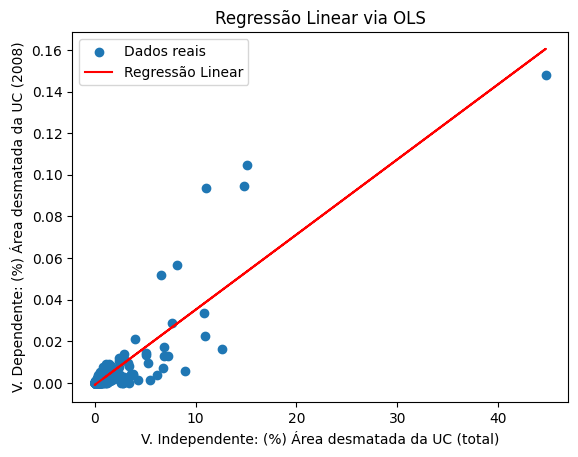

In [34]:
# Estimação por OLS (que é MLE sob erro normal)
model = sm.OLS(y, X).fit()
print(model.summary())
print("\n")

# Fazer previsões
y_pred = model.predict(X)

# Visualizar resultados
plt.scatter(x, y, label='Dados reais')
plt.plot(x, y_pred, color='red', label='Regressão Linear')
plt.title("Regressão Linear via OLS")
plt.xlabel('V. Independente: (%) Área desmatada da UC (total)')
plt.ylabel('V. Dependente: (%) Área desmatada da UC (2008)')
plt.legend()
plt.show()

Estimativas MLE:
beta0 = -0.000988001032751985
beta1 = 0.003611469856415111
sigma = 0.0068871765754274184


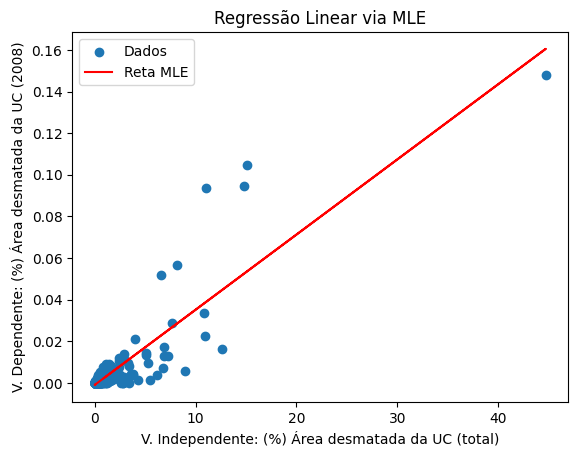

In [35]:
import scipy.optimize as opt

# Definindo a função de log-verossimilhança negativa
# Usamos a parametrização: params = [beta0, beta1, log_sigma]
def neg_log_likelihood(params, x, y):
    beta0, beta1, log_sigma = params
    sigma = np.exp(log_sigma)  # Garante que sigma > 0
    n = len(y)
    residuals = y - (beta0 + beta1 * x)
    # Função de log-verossimilhança negativa:
    nll = 0.5 * n * np.log(2 * np.pi) + n * log_sigma + np.sum(residuals**2) / (2 * sigma**2)
    return nll

# Chute inicial para [beta0, beta1, log_sigma]
initial_guess = [0, 0, 0]

# Minimiza a log-verossimilhança negativa
result = opt.minimize(neg_log_likelihood, initial_guess, args=(x, y))

beta0_hat, beta1_hat, log_sigma_hat = result.x
sigma_hat = np.exp(log_sigma_hat)

print("Estimativas MLE:")
print("beta0 =", beta0_hat)
print("beta1 =", beta1_hat)
print("sigma =", sigma_hat)

# Visualização dos dados e da reta ajustada
plt.scatter(x, y, label='Dados')
plt.plot(x, beta0_hat + beta1_hat * x, color='red', label='Reta MLE')
plt.xlabel('V. Independente: (%) Área desmatada da UC (total)')
plt.ylabel('V. Dependente: (%) Área desmatada da UC (2008)')
plt.legend()
plt.title("Regressão Linear via MLE")
plt.show()

M-estimador de Huber:
Coeficiente: [-9.57572919e-05  2.46275395e-03]
Intercepto: -9.575705127351366e-05


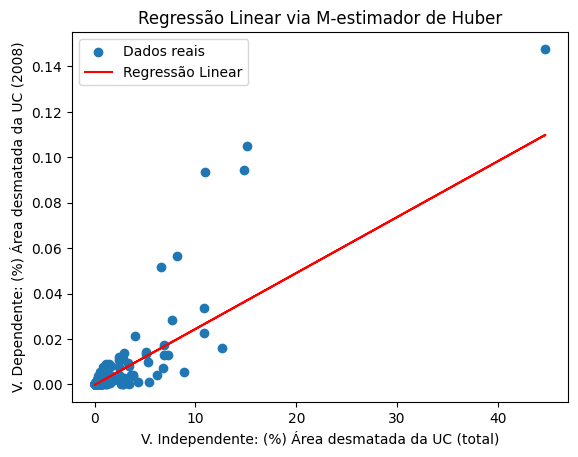

In [36]:
from sklearn.linear_model import HuberRegressor

# Regressão robusta usando Huber
huber = HuberRegressor(epsilon=1.35)
huber.fit(X, y)

# Fazer previsões
y_pred = huber.predict(X)

# Parâmetros estimados
print("M-estimador de Huber:")
print(f"Coeficiente: {huber.coef_}")
print(f"Intercepto: {huber.intercept_}")

# Visualizar resultados
plt.scatter(x, y, label='Dados reais')
plt.plot(x, y_pred, color='red', label='Regressão Linear')
plt.xlabel('V. Independente: (%) Área desmatada da UC (total)')
plt.ylabel('V. Dependente: (%) Área desmatada da UC (2008)')
plt.title('Regressão Linear via M-estimador de Huber')
plt.legend()
plt.show()


# 7. Série temporal
- Desmatamento em UCs
- Componentes da série temporal 
1. Tendência: Não há tendência única (ascendente, descendente ou constante) ao longo do período analisado. A variação de tendência também não é a mesma entre os biomas.
2. Sazonalidade: Os dados não permitem avaliar a sazonalidade neste momento. 
3. Ruído/Resíduo: Verifica-se um aumento mais evidente no desmatamento da Amazônia em 2021, que pode ter ocorrido em função de choques externos (fatores políticos).

4. Média móvel: Para calculá-la seria interessante utilizar dados com menor frequência (disponíveis, mas não utilizados neste trabalho)

In [37]:
colunas_desejadas = ['Bioma', 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
df_baseED_serietemporal = df_baseED[colunas_desejadas]
df_baseED_serietemporal = df_baseED_serietemporal.groupby('Bioma', as_index=False).sum()
df_baseED_serietemporal[2009] = df_baseED_serietemporal[2008]+df_baseED_serietemporal[2009]
df_baseED_serietemporal[2011] = df_baseED_serietemporal[2010]+df_baseED_serietemporal[2011]
df_baseED_serietemporal[2013] = df_baseED_serietemporal[2012]+df_baseED_serietemporal[2013]
df_baseED_serietemporal[2015] = df_baseED_serietemporal[2014]+df_baseED_serietemporal[2015]
df_baseED_serietemporal[2017] = df_baseED_serietemporal[2016]+df_baseED_serietemporal[2017]
df_baseED_serietemporal[2019] = df_baseED_serietemporal[2018]+df_baseED_serietemporal[2019]
df_baseED_serietemporal[2021] = df_baseED_serietemporal[2020]+df_baseED_serietemporal[2021]
df_baseED_serietemporal[2023] = df_baseED_serietemporal[2022]+df_baseED_serietemporal[2023]
df_baseED_serietemporal = df_baseED_serietemporal.drop(columns=[2008,2010,2012,2014,2016,2018,2020,2022])
df_baseED_serietemporal = df_baseED_serietemporal.set_index('Bioma').T

Text(0.5, 1.0, 'Variação bianual no desmatamento em UCs (ha)')

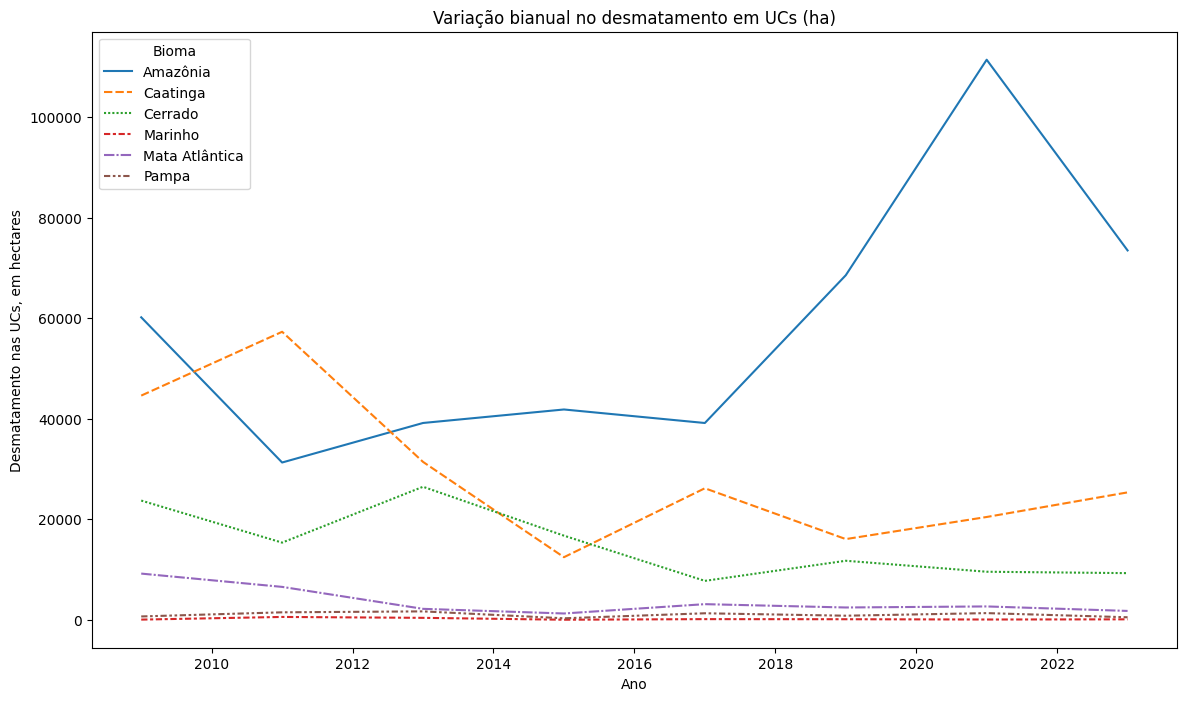

In [38]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=df_baseED_serietemporal)
plt.xlabel('Ano')
plt.ylabel('Desmatamento nas UCs, em hectares')
plt.title('Variação bianual no desmatamento em UCs (ha)')

In [39]:
df_baseED_serietemporal

Bioma,Amazônia,Caatinga,Cerrado,Marinho,Mata Atlântica,Pampa
2009,60169.560000,44605.120000,23736.410000,72.020000,9218.800000,699.32
2011,31302.970000,57292.320000,15377.730000,601.130000,6576.100000,1519.83
2013,39162.110000,31423.240000,26480.160000,421.350000,2211.580000,1707.33
2015,41845.760000,12478.410000,16759.940000,48.100000,1287.450000,331.18
2017,39157.170000,26183.070000,7772.930000,165.890000,3142.650000,1329.54
2019,68528.590000,16078.790000,11768.140000,146.680000,2480.970000,845.32
2021,111378.200000,20472.910000,9587.730000,90.000000,2690.000000,1362.00
2023,73463.586207,25363.935213,9308.295459,125.471331,1796.783995,535.79


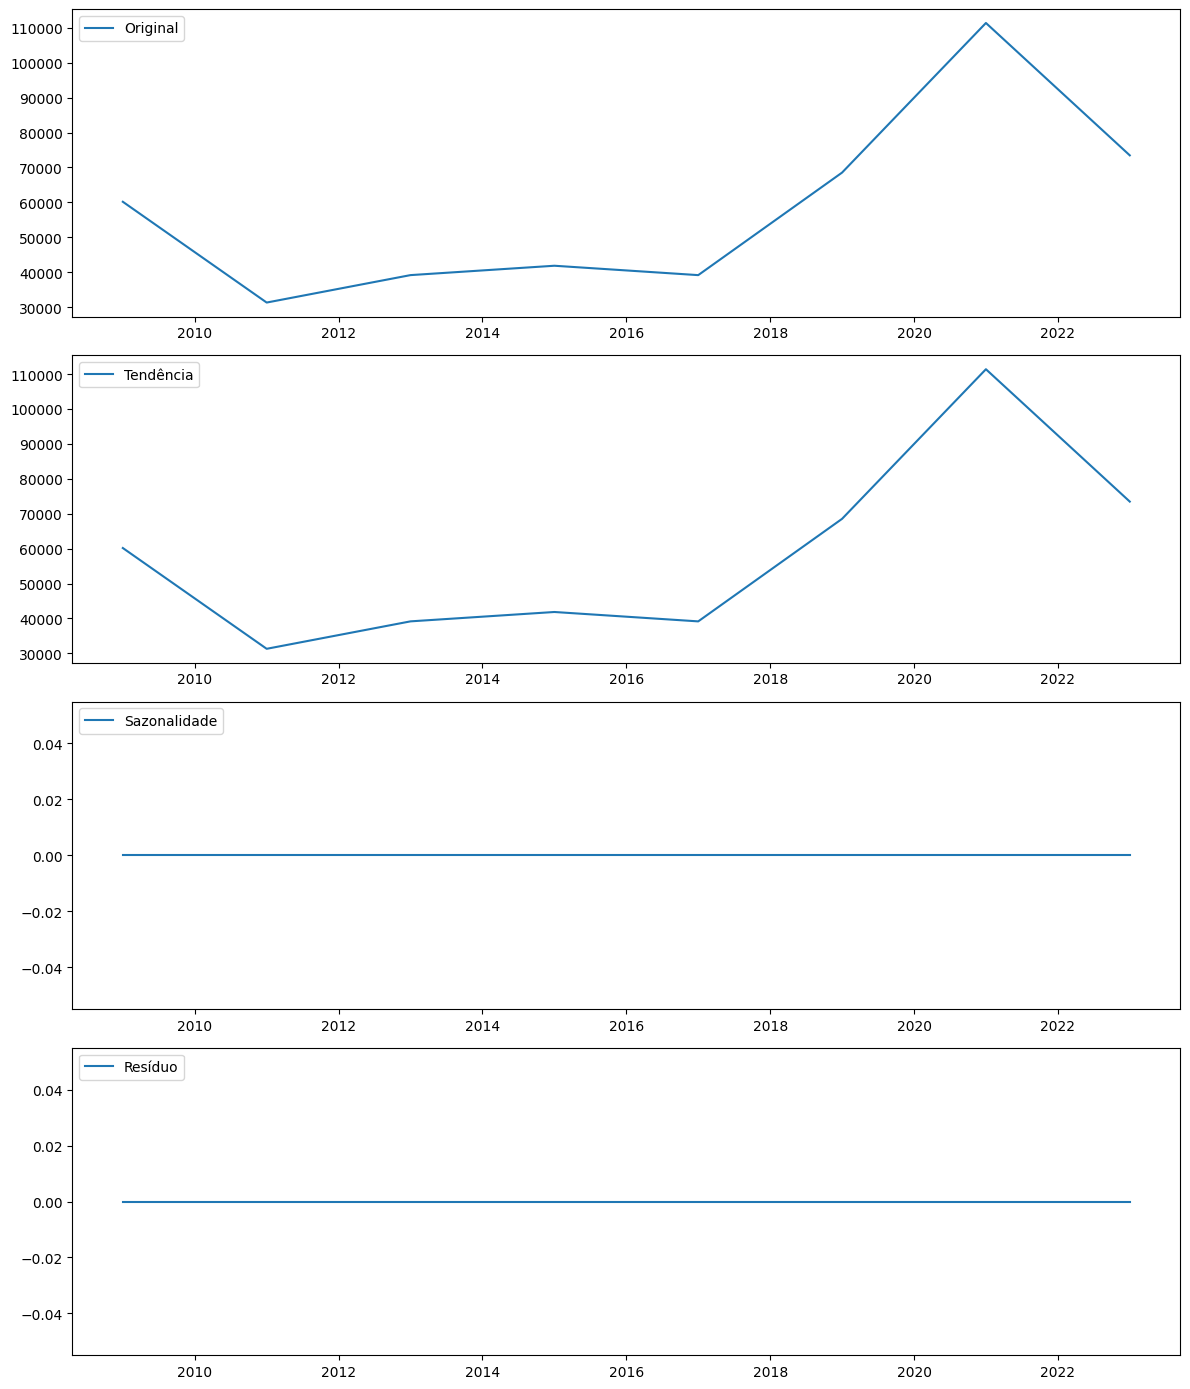

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df_baseED_serietemporal['Amazônia'], period=1)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot dos componentes
plt.figure(figsize=(12, 14))
plt.subplot(411)
plt.plot(df_baseED_serietemporal['Amazônia'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Tendência')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Sazonalidade')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Resíduo')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()